In [1]:
import re
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data_dir = Path(r"C:\Users\myles\OneDrive\Desktop\friction_sweep_4")

folders = sorted(data_dir.glob("*"), key=lambda p: float(p.name))

print("Number of folders found:", len(folders))
for f in folders:
    print(" ", f.name)


def find_table_start(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Time"):
                return i
    raise ValueError(f"No table header found in {path}")


def find_table_end(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Loop"):
                return i
    return None


dataframes = {}          # raw data
dataframes_processed = {} # trimmed + rescaled

for folder in folders:
    mu_folder = folder.name

    run_files = sorted(folder.glob("run_a*_muR*.log"))
    print(f"mu={mu_folder} -> {len(run_files)} run files")

    columns = []
    column_names = []

    for file in run_files:
        m = re.search(r"run_a([0-9.]+)_muR([0-9.]+)", file.stem)
        if not m:
            print(f"  Skipping unrecognised filename: {file.name}")
            continue

        a_str  = m.group(1)
        mu_str = m.group(2)

        start = find_table_start(file)
        end   = find_table_end(file)

        df = pd.read_csv(
            file,
            sep=r'\s+',
            skiprows=start,
            nrows=(end - start) if end is not None else None,
            on_bad_lines="skip",
            engine="python"
        )

        col = df.iloc[:, 4]  # 5th column (stress_xy)
        new_name = f"a{a_str}_mu{mu_str}_stress_xy"
        col = col.rename(new_name)

        columns.append(col)
        column_names.append(new_name)

    paired = sorted(zip(columns, column_names), key=lambda x: float(re.search(r"a([0-9.]+)", x[1]).group(1)))
    columns, column_names = zip(*paired) if paired else ([], [])

    mu_df = pd.concat(columns, axis=1)
    mu_df.columns = column_names
    mu_df.insert(0, "Time", range(len(mu_df)))
    dataframes[mu_folder] = mu_df

    # New processed DataFrame — discard first 200 points and rescale
    mu_df_proc = mu_df.iloc[200:].copy().reset_index(drop=True)
    mu_df_proc["Time"] = range(len(mu_df_proc))

    stress_cols = [c for c in mu_df_proc.columns if c != "Time"]
    mu_df_proc[stress_cols] = mu_df_proc[stress_cols].apply(lambda col: abs(col / 0.01 * 0.1))

    dataframes_processed[mu_folder] = mu_df_proc
    print(f"  -> Raw shape: {mu_df.shape} | Processed shape: {mu_df_proc.shape}")

# Raw:       dataframes["0.1"], dataframes["0.5"], dataframes["1"], dataframes["10"]
# Processed: dataframes_processed["0.1"], dataframes_processed["0.5"], etc.
print("\nDataFrames created for mu =", list(dataframes.keys()))

# Head of each processed DataFrame
for mu, df in dataframes_processed.items():
    print(f"\nProcessed DataFrame for mu={mu}:")
    print(df.head())

Number of folders found: 4
  0.1
  0.5
  1
  10
mu=0.1 -> 14 run files
  -> Raw shape: (3001, 15) | Processed shape: (2801, 15)
mu=0.5 -> 14 run files
  -> Raw shape: (3001, 15) | Processed shape: (2801, 15)
mu=1 -> 14 run files
  -> Raw shape: (3001, 15) | Processed shape: (2801, 15)
mu=10 -> 14 run files
  -> Raw shape: (3001, 15) | Processed shape: (2801, 15)

DataFrames created for mu = ['0.1', '0.5', '1', '10']

Processed DataFrame for mu=0.1:
   Time  a0.006_mu0.1_stress_xy  a0.01_mu0.1_stress_xy  a0.02_mu0.1_stress_xy  \
0     0                0.096487               0.097496               0.099249   
1     1                0.091949               0.095292               0.097010   
2     2                0.093359               0.096054               0.100906   
3     3                0.094724               0.098452               0.101468   
4     4                0.097672               0.103786               0.104239   

   a0.03_mu0.1_stress_xy  a0.06_mu0.1_stress_xy  a0.1_mu0.1_

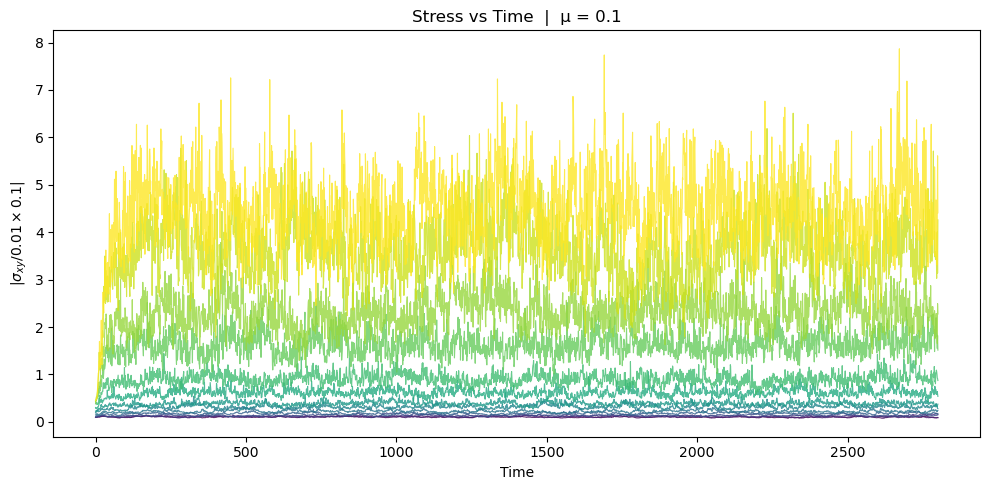

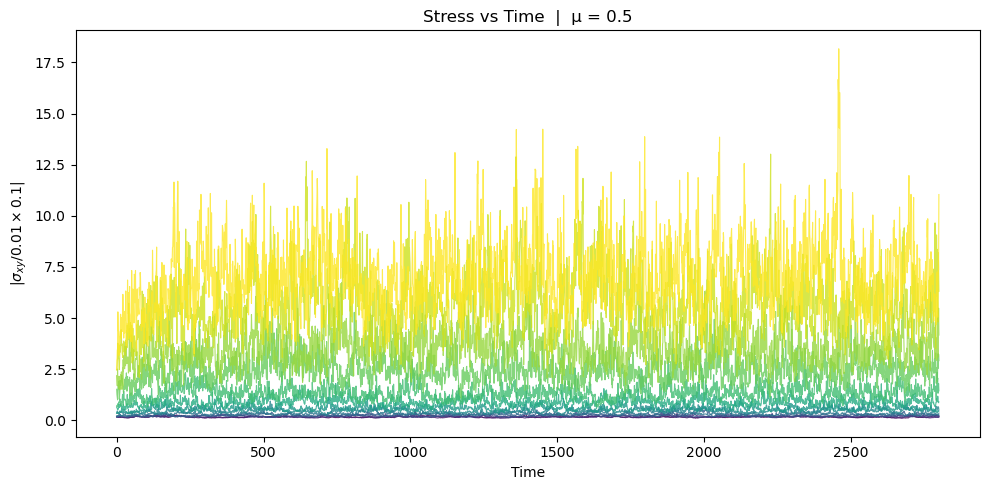

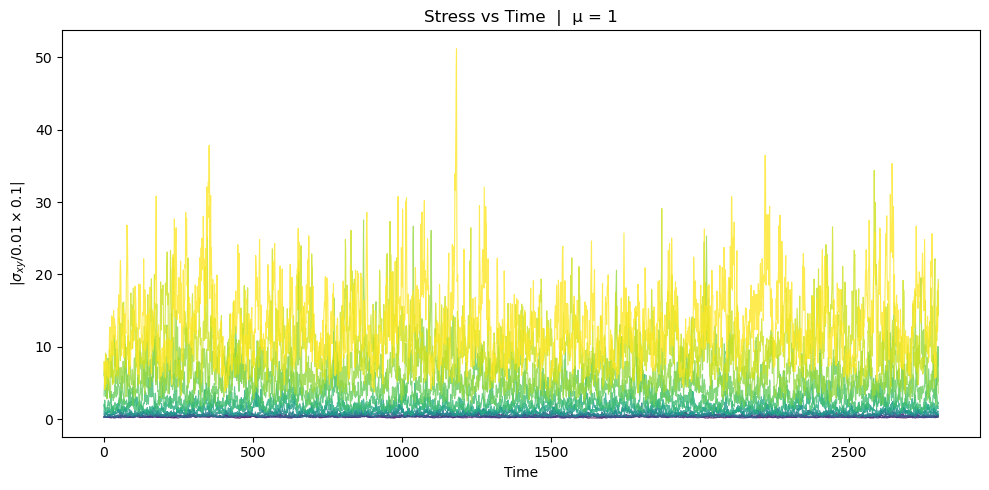

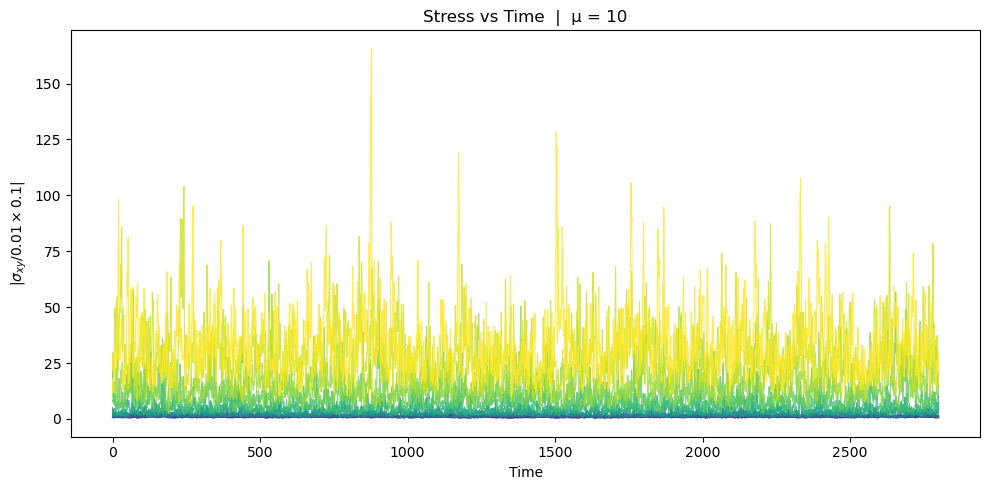

In [2]:
import matplotlib.cm as cm

cmap = cm.viridis
mu_values = list(dataframes_processed.keys())  # ["0.1", "0.5", "1", "10"]

for mu in mu_values:
    df = dataframes_processed[mu]
    stress_cols = [c for c in df.columns if c != "Time"]
    
    colours = cmap(np.linspace(0, 1, len(stress_cols)))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for col, colour in zip(stress_cols, colours):
        ax.plot(df["Time"], df[col], color=colour, linewidth=0.8, alpha=0.8)
    
    ax.set_title(f"Stress vs Time  |  μ = {mu}")
    ax.set_xlabel("Time")
    ax.set_ylabel(r"$|\sigma_{xy} / 0.01 \times 0.1|$")
    plt.tight_layout()
    plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
C:\Users\myles\AppData\Local\Temp\ipykernel_54800\769677192.py:42: SyntaxWarning: invalid escape sequence '\m'
  ax.legend(title='$\mu_s =1$', fontsize=13, handlelength=1.5, borderpad=0.4,


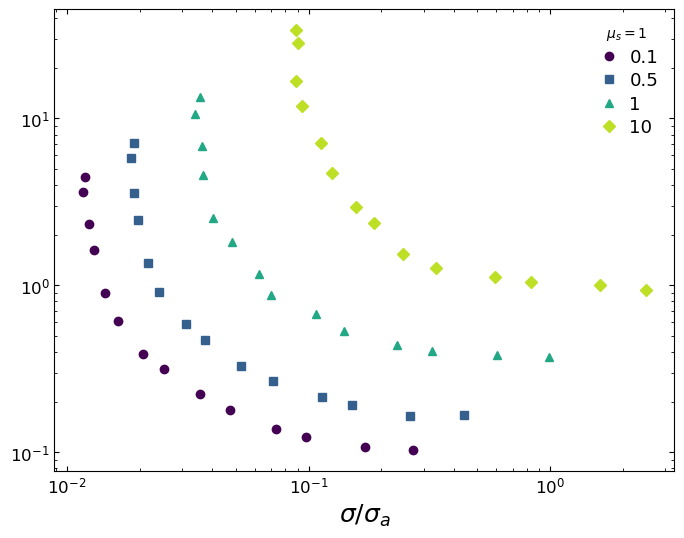

In [10]:
# Trim first 200 points from raw dataframes (without rescaling)
dataframes_trimmed = {}
for mu, df in dataframes.items():
    mu_df_trim = df.iloc[200:].copy().reset_index(drop=True)
    mu_df_trim["Time"] = range(len(mu_df_trim))
    dataframes_trimmed[mu] = mu_df_trim

# Markers and colours for each mu value
markers = ['o', 's', '^', 'D']
colours = plt.cm.viridis(np.linspace(0, 0.9, len(mu_values)))

fig, ax = plt.subplots(figsize=(8, 6))

for (mu, marker, colour) in zip(mu_values, markers, colours):
    df_visc = dataframes_processed[mu]   # rescaled — this is viscosity
    df_raw  = dataframes_trimmed[mu]     # raw trimmed — for x-axis

    stress_cols = [c for c in df_visc.columns if c != "Time"]

    x_vals = []
    y_vals = []

    for col in stress_cols:
        # Extract a value from column name e.g. a0.006_mu0.1_stress_xy
        a_val = float(re.search(r"a([0-9.]+)", col).group(1))

        # Y: mean viscosity (already rescaled)
        mean_visc = df_visc[col].mean()

        # X: mean raw stress (trimmed) / (2 * pi * a)
        raw_col = df_raw[col]
        mean_x = abs(raw_col.mean() / (2 * np.pi * a_val))

        x_vals.append(mean_x)
        y_vals.append(mean_visc)

    ax.plot(x_vals, y_vals, marker=marker, color=colour,
            linestyle='', linewidth=1, markersize=6, label=f"{mu}")

ax.set_xlabel(r"$\sigma / \sigma_a $", fontsize=18)
#ax.set_ylabel(r"$\eta_r$", fontsize=18)
ax.legend(title='$\mu_s =1$', fontsize=13, handlelength=1.5, borderpad=0.4, 
                  labelspacing=0.3, handletextpad=0.4, frameon=False)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.minorticks_on()
plt.yscale('log')
plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
import pickle
fig = plt.gcf()
with open('fric_sweep_2.pkl', 'wb') as f:
    pickle.dump(fig, f)
plt.show()